<a href="https://colab.research.google.com/github/jforti369/Programas_vasculares/blob/main/MCUVA_v02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#####################################################################################
## MCUVA – de “Modelo de Classificação de Úlceras Venosas e Arteriais” – versão 2.0.
#####################################################################################

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#pip install -U albumentations

In [3]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
import unicodedata
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
import torchvision.models as models
import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
import pandas as pd

/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.5' (you have '2.0.4'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


#=============================================================================
#### 1. Funções auxiliares e definição do Dataset
#=============================================================================

In [4]:
def normalize_text(text):
    nfkd_form = unicodedata.normalize('NFKD', text)
    return "".join([c for c in nfkd_form if not unicodedata.combining(c)]).lower()

def extract_class(annotation):
    if "class" in annotation:
        return annotation["class"]
    if "annotations" in annotation and len(annotation["annotations"]) > 0:
        details = annotation["annotations"][0].get("details", {})
        for key, value in details.items():
            if "ulcera" in normalize_text(key):
                return value
    return ""

class UlcerDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.samples = []  # lista de (caminho_imagem, label)
        for patient in os.listdir(root_dir):
            patient_path = os.path.join(root_dir, patient)
            if not os.path.isdir(patient_path):
                continue
            print(f"\nProcessando paciente: {patient}")
            photo_dir = os.path.join(patient_path, "Fotografias")
            label_dir = os.path.join(patient_path, "Rotulagem")
            if not os.path.isdir(photo_dir) or not os.path.isdir(label_dir):
                print(f"  Estrutura ausente para {patient} (espera: 'Fotografias' e 'Rotulagem').")
                continue
            json_files = [f for f in os.listdir(label_dir) if f.lower().endswith('.json')]
            if not json_files:
                print(f"  Nenhum arquivo JSON encontrado em {label_dir}")
                continue
            for json_file in json_files:
                json_path = os.path.join(label_dir, json_file)
                try:
                    with open(json_path, 'r') as f:
                        annotation = json.load(f)
                except Exception as e:
                    print(f"  Erro ao ler {json_path}: {e}")
                    continue
                # Usa campo "filename" se existir; senão, assume nome base + .jpg
                if "filename" in annotation:
                    image_name = annotation["filename"]
                else:
                    base = os.path.splitext(json_file)[0]
                    image_name = base + ".jpg"
                image_path = os.path.join(photo_dir, image_name)
                if not os.path.exists(image_path):
                    alt_image_name = os.path.splitext(json_file)[0] + ".png"
                    image_path = os.path.join(photo_dir, alt_image_name)
                    if not os.path.exists(image_path):
                        print(f"  Imagem não encontrada para {json_file} em {photo_dir}")
                        continue
                classe = extract_class(annotation)
                classe_norm = normalize_text(classe)
                print(f"  {json_file} -> {os.path.basename(image_path)} | Classe: '{classe_norm}'")
                if "venosa" in classe_norm:
                    label = 0
                elif "arterial" in classe_norm:
                    label = 1
                else:
                    print(f"  Ignorando {json_file}: classe '{classe}' não identificada.")
                    continue
                self.samples.append((image_path, label))
            print(f"  Total de amostras para {patient}: {len([s for s in self.samples if patient in s[0]])}")
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        image_path, label = self.samples[idx]
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Erro ao ler a imagem: {image_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
        return image, label

#=============================================================================
#### 2. Transformações de Dados (Treino e Validação)
#=============================================================================

In [5]:
train_transform = A.Compose([
    A.Resize(height=480, width=640),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.2),
    A.Affine(
        translate_percent=(-0.1, 0.1),
        scale=(0.9, 1.1),
        rotate=(-90, 90),
        shear=0,
        border_mode=cv2.BORDER_REFLECT,
        p=0.5
    ),
    A.RGBShift(r_shift_limit=10, g_shift_limit=10, b_shift_limit=10, p=0.5),
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=20, val_shift_limit=20, p=0.5),
    A.OneOf([
        A.GaussianBlur(blur_limit=3, p=0.1),
        A.MedianBlur(blur_limit=3, p=0.1)
    ], p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(height=480, width=640),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

#=============================================================================
#### 3. Carregamento do Dataset e Criação dos DataLoaders
#=============================================================================

In [6]:
root_dir = '/content/drive/MyDrive/Teste'
full_dataset = UlcerDataset(root_dir=root_dir, transform=train_transform)
print(f"\nTotal de amostras filtradas: {len(full_dataset)}")
if len(full_dataset) == 0:
    raise ValueError("Nenhuma amostra encontrada. Verifique a estrutura dos diretórios.")

# Dividir em treino (70%), validação (15%) e teste (15%)
total_size = len(full_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])
# Use a transformação de validação para os conjuntos de validação e teste
val_dataset.dataset.transform = val_transform
test_dataset.dataset.transform = val_transform

# Calcular pesos para sampler ponderado
labels_all = [label for _, label in full_dataset.samples]
counts = Counter(labels_all)
sample_weights = [1.0 / counts[label] for _, label in full_dataset.samples]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)


Processando paciente: Adenildo_Francisco_Pereira
  Adenildo_Francisco_Pereira_002.json -> Adenildo_Francisco_Pereira_002.png | Classe: 'ulcera arterial'
  Adenildo_Francisco_Pereira_014.json -> Adenildo_Francisco_Pereira_014.png | Classe: 'ulcera arterial'
  Adenildo_Francisco_Pereira_003.json -> Adenildo_Francisco_Pereira_003.png | Classe: 'ulcera arterial'
  Adenildo_Francisco_Pereira_012.json -> Adenildo_Francisco_Pereira_012.png | Classe: 'ulcera arterial'
  Adenildo_Francisco_Pereira_004.json -> Adenildo_Francisco_Pereira_004.png | Classe: 'ulcera arterial'
  Adenildo_Francisco_Pereira_009.json -> Adenildo_Francisco_Pereira_009.png | Classe: 'ulcera arterial'
  Adenildo_Francisco_Pereira_008.json -> Adenildo_Francisco_Pereira_008.png | Classe: 'ulcera arterial'
  Adenildo_Francisco_Pereira_013.json -> Adenildo_Francisco_Pereira_013.png | Classe: 'ulcera arterial'
  Adenildo_Francisco_Pereira_010.json -> Adenildo_Francisco_Pereira_010.png | Classe: 'ulcera arterial'
  Adenildo_Fra

#=============================================================================
#### 4. Definição e Otimização do Modelo
#=============================================================================

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Exemplo: Fine-tuning do ResNet50, descongelando layer4 e adicionando dropout
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
for param in model.parameters():
    param.requires_grad = False
for param in model.layer4.parameters():
    param.requires_grad = True
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(num_features, 2)
)
model = model.to(device)

# Definir loss com pesos inversos
weights = [total_size / counts[i] for i in range(2)]
weights = torch.tensor(weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
print("Pesos usados na loss:", weights)

# Otimizador AdamW
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.001)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 177MB/s]


Pesos usados na loss: tensor([1.4342, 3.3033], device='cuda:0')


#=============================================================================
#### 5. Função MixUp para Aumento de Dados
#=============================================================================

In [8]:
def mixup_data(x, y, alpha=0.2):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

#=============================================================================
#### 6. Loop de Treinamento com Early Stopping (paciencia = 3)
#=============================================================================

In [9]:
# Supondo que 'sample_weights' foi calculado para o full_dataset
sample_weights = [1.0 / counts[label] for _, label in full_dataset.samples]

# Após dividir em subsets, obtenha os índices do subset de treino:
train_indices = train_dataset.indices  # train_dataset é um Subset

# Calcule os pesos apenas para esses índices:
subset_weights = [sample_weights[i] for i in train_indices]

# Crie o sampler para o subset de treino:
sampler = WeightedRandomSampler(weights=subset_weights, num_samples=len(subset_weights), replacement=True)

# Crie o DataLoader usando o sampler:
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=0)

In [10]:
%%time
num_epochs = 40
global_step = 0
best_val_loss = float('inf')
patience = 3
early_stopping_counter = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training", leave=False)
    for images, labels in train_bar:
        images, labels_a, labels_b, lam = mixup_data(images.to(device), labels.to(device), alpha=0.2)
        optimizer.zero_grad()
        outputs = model(images)
        loss = lam * criterion(outputs, labels_a) + (1 - lam) * criterion(outputs, labels_b)
        loss.backward()
        optimizer.step()

        global_step += 1
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels.to(device)).sum().item()
        train_bar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    # Validação
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation", leave=False)
    with torch.no_grad():
        for images, labels in val_bar:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            val_bar.set_postfix(loss=f"{loss.item():.4f}")

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        early_stopping_counter = 0
        print("  Melhor modelo salvo.")
    else:
        early_stopping_counter += 1
        print(f"  Early stopping counter: {early_stopping_counter}/{patience}")
        if early_stopping_counter >= patience:
            print("Early stopping acionado. Interrompendo o treinamento.")
            break

Epoch [1/40] Train Loss: 0.3516 | Train Acc: 0.7273 | Val Loss: 0.1122 | Val Acc: 0.9459
  Melhor modelo salvo.


Epoch [2/40] Train Loss: 0.2190 | Train Acc: 0.6984 | Val Loss: 0.1381 | Val Acc: 0.9324
  Early stopping counter: 1/3


Epoch [3/40] Train Loss: 0.2096 | Train Acc: 0.7042 | Val Loss: 0.0898 | Val Acc: 0.9932
  Melhor modelo salvo.


Epoch [4/40] Train Loss: 0.1903 | Train Acc: 0.7532 | Val Loss: 0.0654 | Val Acc: 0.9932
  Melhor modelo salvo.


Epoch [5/40] Train Loss: 0.1506 | Train Acc: 0.7100 | Val Loss: 0.1014 | Val Acc: 0.9662
  Early stopping counter: 1/3


Epoch [6/40] Train Loss: 0.1691 | Train Acc: 0.7460 | Val Loss: 0.1244 | Val Acc: 0.9595
  Early stopping counter: 2/3


Epoch [7/40] Train Loss: 0.1996 | Train Acc: 0.7706 | Val Loss: 0.1049 | Val Acc: 0.9797
  Early stopping counter: 3/3
Early stopping acionado. Interrompendo o treinamento.
CPU times: user 30min 35s, sys: 3min 37s, total: 34min 13s
Wall time: 51min 29s


#=============================================================================
#### 7. Visualização das Curvas de Treinamento e Validação
#=============================================================================

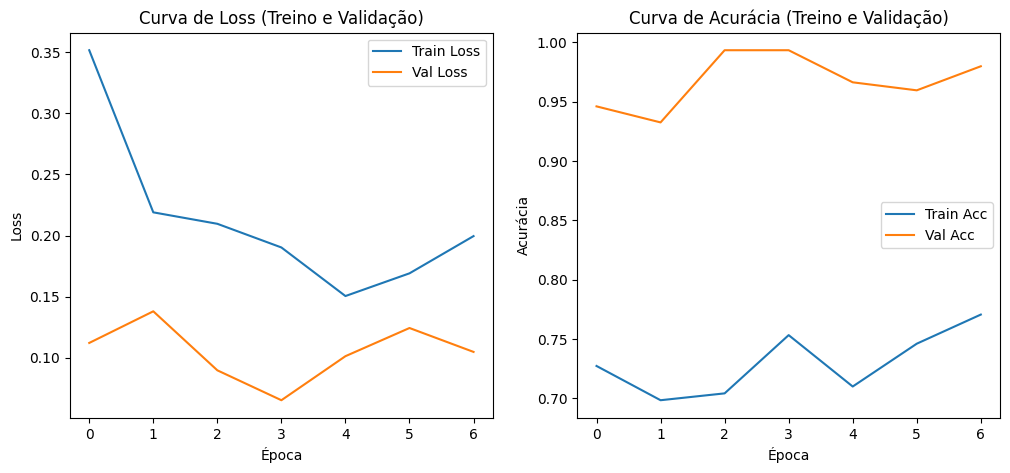

In [11]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Curva de Loss (Treino e Validação)')
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accuracies, label='Train Acc')
plt.plot(val_accuracies, label='Val Acc')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Curva de Acurácia (Treino e Validação)')
plt.legend()
plt.show()

#=============================================================================
#### 8. Avaliação no Conjunto de Teste e Curva ROC
#=============================================================================

<ipython-input-12-c539ca7172e5>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))


Matriz de Confusão:
[[108   0]
 [  5  37]]


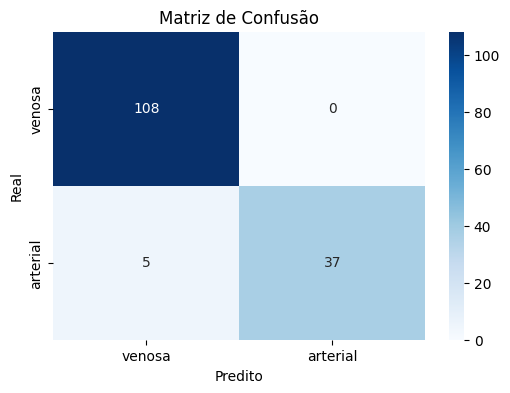

Relatório de Classificação:
              precision    recall  f1-score     support
venosa         0.955752  1.000000  0.977376  108.000000
arterial       1.000000  0.880952  0.936709   42.000000
accuracy       0.966667  0.966667  0.966667    0.966667
macro avg      0.977876  0.940476  0.957042  150.000000
weighted avg   0.968142  0.966667  0.965989  150.000000


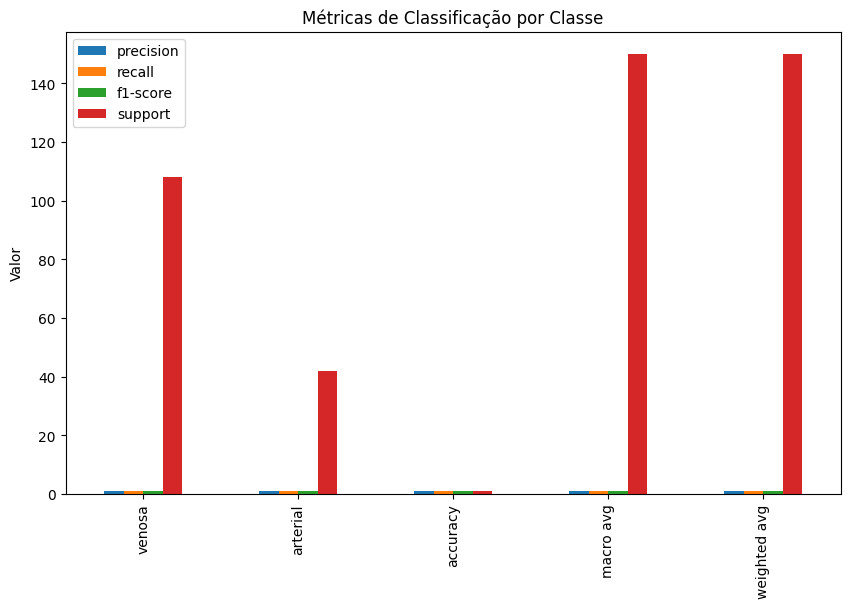

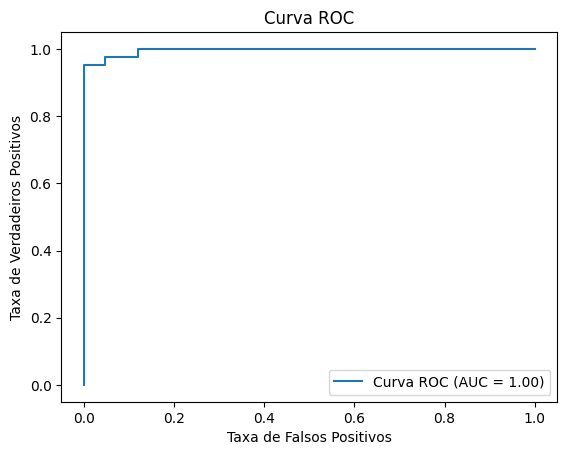

In [12]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print("Matriz de Confusão:")
print(cm)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['venosa', 'arterial'], yticklabels=['venosa', 'arterial'])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.show()

report = classification_report(all_labels, all_preds, target_names=['venosa', 'arterial'], output_dict=True)
df_report = pd.DataFrame(report).transpose()
print("Relatório de Classificação:")
print(df_report)
df_report.plot(kind='bar', figsize=(10,6))
plt.title("Métricas de Classificação por Classe")
plt.ylabel("Valor")
plt.show()

# Curva ROC e AUC para a classe "arterial" (assumindo que a classe 1 representa arterial)
# Para calcular a curva ROC, precisamos das probabilidades da classe 1:
all_probs = []
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]  # Probabilidade da classe 1
        all_probs.extend(probs.cpu().numpy())

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.legend()
plt.show()

#=============================================================================
#### 9. Visualização da Arquitetura do Modelo com torchviz (Grad-CAM também pode ser incluído)
#=============================================================================

In [15]:
pip install torchviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 81.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchviz import make_dot

# Cria uma entrada dummy com o mesmo tamanho que as imagens utilizadas
dummy_input = torch.randn(1, 3, 480, 640, device=device)
output = model(dummy_input)

# Gera o gráfico das operações e parâmetros do modelo
dot = make_dot(output, params=dict(model.named_parameters()))
dot.format = "png"
dot.render("model_architecture")
print("Diagrama da arquitetura do modelo salvo como 'model_architectureV2.png'.")

Diagrama da arquitetura do modelo salvo como 'model_architectureV2.png'.


#=============================================================================
#### 10. Ensemble - Exemplo de combinação de dois modelos
#=============================================================================

In [17]:
model1 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
num_features1 = model1.fc.in_features
model1.fc = nn.Linear(num_features1, 2)
model1 = model1.to(device)

In [18]:
# Exemplo: instancie o model2 como um ResNet18 (ou outro modelo desejado)
model2 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
num_features2 = model2.fc.in_features
model2.fc = nn.Linear(num_features2, 2)
model2 = model2.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 125MB/s]


In [19]:
with torch.no_grad():
     outputs1 = model1(images.to(device))
     outputs2 = model2(images.to(device))
     outputs_ensemble = (outputs1 + outputs2) / 2.0
     _, predicted = torch.max(outputs_ensemble, dim=1)

#=============================================================================
#### 11. Interpretabilidade - Exemplo com Grad-CAM usando torchcam
#=============================================================================

In [20]:
pip install torchcam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.7 MB/s eta 0:00:00


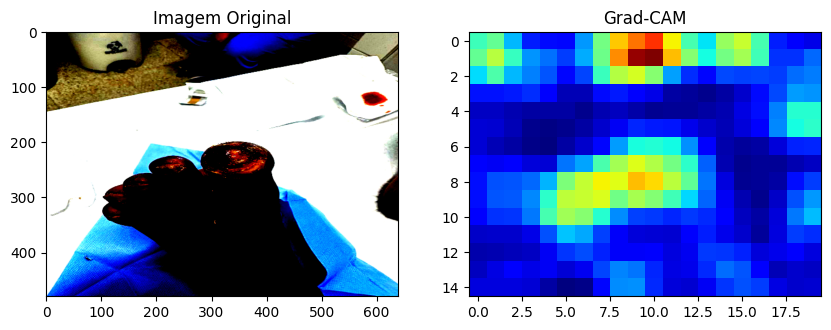

In [21]:
try:
    from torchcam.methods import SmoothGradCAMpp
    # Crie o objeto Grad-CAM para a última camada convolucional (ajuste se necessário)
    cam_extractor = SmoothGradCAMpp(model, target_layer='layer4')

    def generate_gradcam(image_tensor):
        # Certifique-se de que o input requer gradiente para os hooks
        image_tensor.requires_grad_()
        output = model(image_tensor)
        # Usa o índice da classe prevista para registrar os gradientes
        pred_class = output.argmax(dim=1).item()
        activation_map = cam_extractor(pred_class, output)
        return activation_map

    # Exemplo: visualize Grad-CAM para a primeira imagem do dataset de teste
    image, label = full_dataset[0]
    image_tensor = image.unsqueeze(0).to(device)
    cam = generate_gradcam(image_tensor)
    # Supondo que cam seja uma lista; obtenha o primeiro tensor, remova dimensões extras e converta para numpy
    cam_tensor = cam[0].squeeze(0).cpu().numpy()

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(image.permute(1,2,0).cpu().numpy())
    plt.title("Imagem Original")
    plt.subplot(1,2,2)
    plt.imshow(cam_tensor, cmap='jet')
    plt.title("Grad-CAM")
    plt.show()
except Exception as e:
    print(f"Erro na geração do Grad-CAM: {e}")

#=================================================
#### 12. Demonstração de Inferência em uma Imagem
#=================================================
#### Função para realizar a inferência em uma única imagem. Essa função aplica o mesmo pré-processamento do conjunto de validação e retorna a predição.

In [24]:
def load_model_for_inference(model_path, device):
    # Crie uma nova instância do modelo sem os hooks do Grad-CAM
    model_inf = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    num_features = model_inf.fc.in_features
    model_inf.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(num_features, 2)
    )
    model_inf.load_state_dict(torch.load(model_path, map_location=device))
    model_inf = model_inf.to(device)
    model_inf.eval()
    return model_inf

def predict_image(image_path, model, transform, device):
    """
    Recebe o caminho de uma imagem, aplica as transformações e retorna a predição.
    """
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Imagem não encontrada: {image_path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    augmented = transform(image=image)
    image_tensor = augmented['image'].unsqueeze(0).to(device)

    # Realiza a inferência (sem hooks interferindo)
    model.eval()
    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()
    return predicted_class, probabilities.cpu().numpy()

# Caminho do modelo salvo (por exemplo, "best_model.pth")
model_path = "best_model.pth"

# Carregue um modelo exclusivo para inferência (sem hooks de Grad-CAM)
model_inference = load_model_for_inference(model_path, device)


# Exemplo de inferência em uma imagem
test_image_path = '/content/drive/MyDrive/MESTRADO/Pasta_acadêmicas_Projeto/Fotos dos pacientes Originais/Túlio Vinícios de Oliveira/06 12 2023/IMG_8835.PNG'
pred_class, probs = predict_image(test_image_path, model_inference, val_transform, device)
class_names = ['venosa', 'arterial']
print(f"Previsão: {class_names[pred_class]}  - Probabilidades: {probs}")

<ipython-input-24-71d3acc4d985>:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_inf.load_state_dict(torch.load(model_path, map_location=device))


Previsão: venosa  - Probabilidades: [[0.68446505 0.31553495]]
